### Задача 

Обучить архитектуру нейросети на MNIST и применить алгоритм детекции на холсте рукописных цифр. Продемонстрировать результаты

In [81]:
import torch, numpy as np
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [82]:
transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(0, 1)
])

In [83]:
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=8, shuffle=True)

In [84]:
testset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(testset, batch_size=8, shuffle=False)

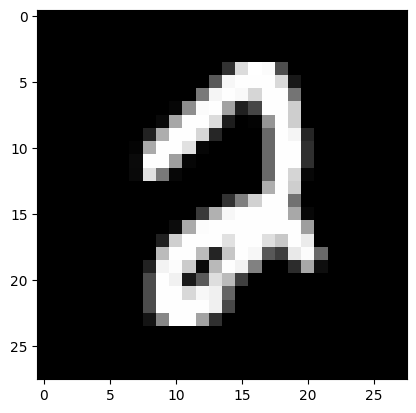

In [85]:
plt.imshow(next(iter(trainloader))[0][0][0], cmap='grey')

In [86]:
class CNN(nn.Module):
    def __init__(self, in_l, out_f):
        super().__init__()
        self.conv1 = nn.Conv2d(in_l, 4, kernel_size=4)
        self.pool1 = nn.AvgPool2d(2, stride=2)

        self.conv2 = nn.Conv2d(4, 10, kernel_size=4, stride=2)
        self.pool2 = nn.AvgPool2d(2, stride=2)

        self.seq = nn.Sequential(
            nn.Linear(2*2*10, 30),
            nn.ReLU(),
            nn.Linear(30, out_f)
        )

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, 2*2*10)
        x = self.seq(x)
        return x

In [87]:
from tqdm import tqdm

 25%|██▌       | 1/4 [00:17<00:53, 17.68s/it]

0 :: 0.3048520601757414


 50%|█████     | 2/4 [00:33<00:33, 16.86s/it]

1 :: 0.1623025389191093


 75%|███████▌  | 3/4 [00:50<00:16, 16.57s/it]

2 :: 0.14023369914341213


100%|██████████| 4/4 [01:07<00:00, 16.77s/it]

3 :: 0.12623782921762103


CNN(
  (conv1): Conv2d(1, 4, kernel_size=(4, 4), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(4, 10, kernel_size=(4, 4), stride=(2, 2))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (seq): Sequential(
    (0): Linear(in_features=40, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=10, bias=True)
  )
)

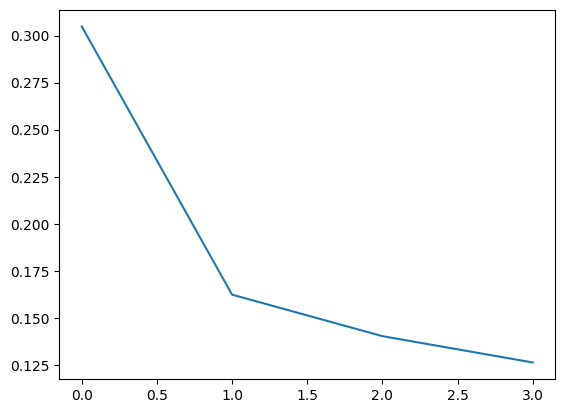

In [88]:
net = CNN(1, 10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.005)

def train(trainloader, model, criterion, optimizer, epoch=4):
    history_loss = []
    for e in tqdm(range(epoch)):
        e_loss = []
        for X, y in trainloader:
            y_pred = model(X)

            loss = criterion(y_pred, y)
            e_loss.append(loss.item())
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()
        print(e, '::', np.mean(e_loss))
        history_loss.append(np.mean(e_loss))
    plt.plot(history_loss)
    return model


train(trainloader, net, criterion, optimizer)

In [89]:
X, y = next(iter(test_loader))

y_pred = net(X)
print(y_pred.softmax(dim=1).argmax(dim=1),y, sep='\n')

tensor([7, 2, 1, 0, 4, 1, 4, 9])
tensor([7, 2, 1, 0, 4, 1, 4, 9])


In [90]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        y_pred = net(images)
        _, predicted = torch.max(y_pred, 1)
        
        c = (predicted.cpu().detach() == labels)
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

classes = list(range(10))
for i in range(10):
    print(f'Accuracy of {classes[i]:5} : {100 * class_correct[i] / class_total[i]:.0f}%')

Accuracy of     0 : 99%
Accuracy of     1 : 98%
Accuracy of     2 : 94%
Accuracy of     3 : 96%
Accuracy of     4 : 99%
Accuracy of     5 : 97%
Accuracy of     6 : 96%
Accuracy of     7 : 98%
Accuracy of     8 : 95%
Accuracy of     9 : 93%


### Выделим цифры из холста и подпишем результат их распознования нашей моделью.

In [91]:
import cv2
from PIL import Image

In [92]:
image = cv2.imread("./img.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 200, 300, apertureSize=5)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

bboxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w < 10 or h < 20: continue
    bboxes.append([(x, y), (x + w, y + h)])

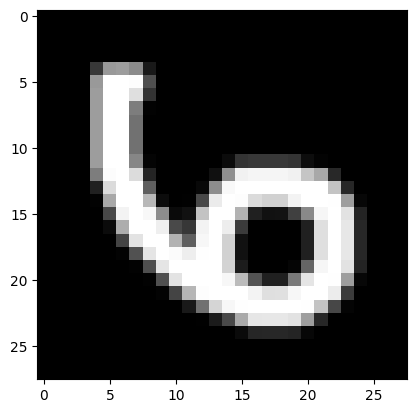

In [93]:
f, s = bboxes[0]
roi = 255 - gray[f[1]:s[1], f[0]:s[0]]

def pad_to_square(roi, margin=0.2):
    h, w = roi.shape
    margin = int(max(h, w) * margin)
    size = max(h, w) + margin * 2
    square = np.zeros((size, size), dtype=roi.dtype)
    y = (size - h) // 2
    x = (size - w) // 2
    square[y:y+h, x:x+w] = roi
    roi_pil = Image.fromarray(square)
    resizer = transforms.Resize((28, 28))
    return resizer(roi_pil)

square_roi = pad_to_square(roi)

plt.imshow(square_roi, cmap='gray')
plt.show()

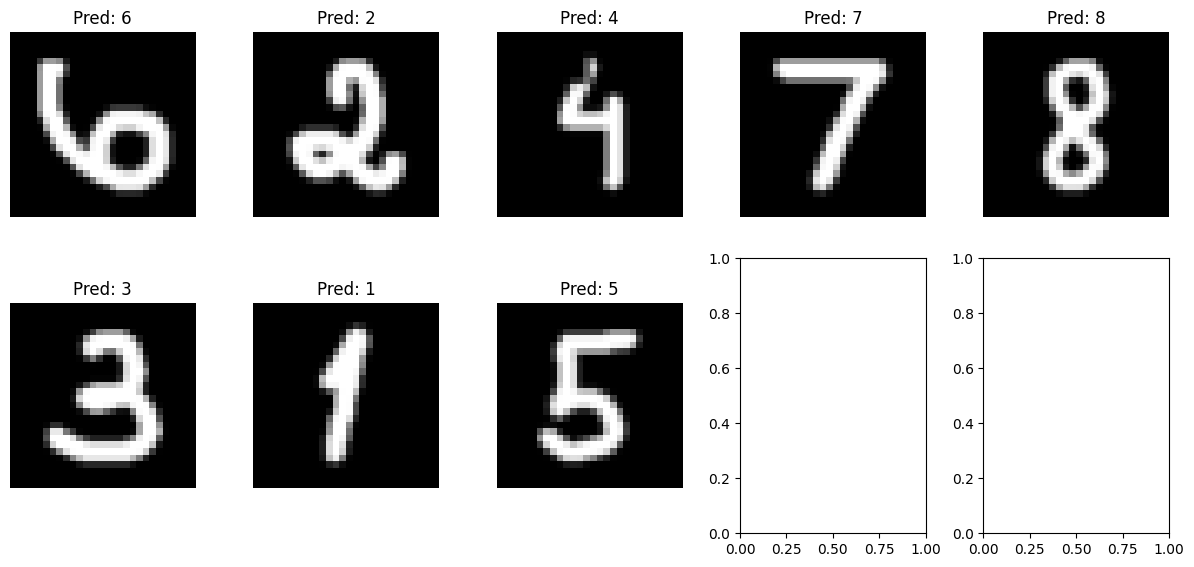

In [94]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i, (f, s) in enumerate(bboxes[:10]):
    
    tmp = gray.copy()
    for ff, ss in bboxes[:10]:
        if (ff, ss) != (f, s):
            tmp[ff[1]:ss[1], ff[0]:ss[0]] = 255

    roi = 255 - tmp[f[1]:s[1], f[0]:s[0]]
    
    resized = pad_to_square(roi)
    
    tensor = transform(resized).unsqueeze(0)
    
    with torch.no_grad():
        y_pred = net(tensor)
        _, predicted = torch.max(y_pred, 1)
        pred_label = predicted.item()
    
    axes[i].imshow(resized, cmap='gray')
    axes[i].set_title(f'Pred: {pred_label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

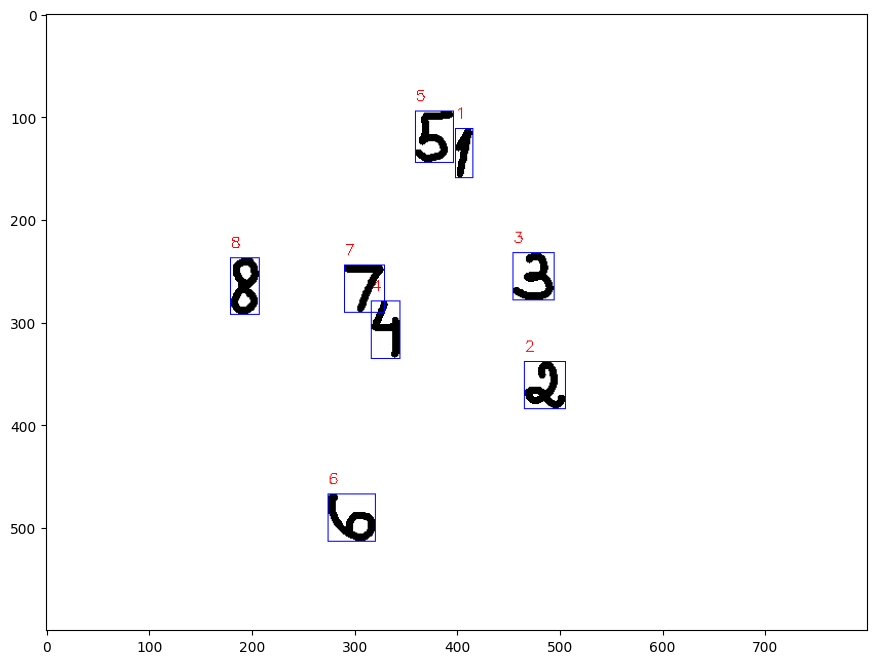

In [95]:
result_image = image.copy()

for i, (f, s) in enumerate(bboxes):
    
    tmp = gray.copy()
    for ff, ss in bboxes:
        if (ff, ss) != (f, s):
            tmp[ff[1]:ss[1], ff[0]:ss[0]] = 255

    roi = 255 - tmp[f[1]:s[1], f[0]:s[0]]
    resized = pad_to_square(roi)
    tensor = transform(resized).unsqueeze(0)
    
    with torch.no_grad():
        y_pred = net(tensor)
        _, predicted = torch.max(y_pred, 1)
        pred_label = predicted.item()
    
    cv2.rectangle(result_image, f, s, (255, 0, 0), 1)
    cv2.putText(result_image, f'{pred_label}', (f[0], f[1]-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_image_rgb)
plt.show()